<img src="https://raw.githubusercontent.com/egiuse25/APS/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Emilia Giusepponi


# Consigna
## Ejercicio 1:  
En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de $B$ bits en un rango de  $±V_F$ Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

. frecuencia f0 arbitraria, por ejemplo $f_0=f_S/N=Δf$
 
. energía normalizada, es decir energía (o varianza) unitaria

Con respecto a los parámetros de la secuencia de ruido, diremos que:

será de carácter aditivo, es decir la señal que entra al ADC será $s_R=s+n$

. Siendo n la secuencia que simula la interferencia, y s la senoidal descrita anteriormente.

. La potencia del ruido será $P_n=k_n.P_q$ W siendo el factor k una escala para la potencia del ruido de cuantización $P_q = \frac{q^2}{12}$

. finalmente, n será incorrelado y Gaussiano.

El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000 Hz y tendrá un rango analógico de $±V_F=2$ Volts.

Se pide:

a) Generar el siguiente resultado producto de la experimentación. $B$ = 4 bits, $k_n$=1

b) Analizar para una de las siguientes configuraciones $B$ = ̣{4, 8 y 16} bits, $k_n$={1/10,1,10}. 

Discutir los resultados respecto a lo obtenido en a).

Bonus:

💎 Encontrar la relación entre la cantidad de B bits del ADC y el SNR de la señal digitalizada. (Ver Holton. DSP Principles and App. 6.7 ADC Quantization pag. 387 )

🤯 Simular el efecto del aliasing junto con el muestreo.



# Desarrollo 
## Definición de función seno
Para empezar, se comienza definiendo la función seno dada por:
$$x(t) = DC + A \cdot \sin(2\pi \cdot f \cdot t + \phi)$$
Siendo en el código:

• Señal senoidal ($x(t)$) = `xx`.

• Desplazamiento en el eje Y (Valor medio) ($DC$) = `dc`.

• Amplitud ($A$) = `vmax`.

• Frecuencia angular ($2\pi \cdot f $) = `2 * np.pi * ff`.

• Fase ($\phi$) = `ph`.

In [1]:
import numpy as np

#DEFINICION DE FUNCION SENO
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs # Tiempo entre cada muestra
    tt = np.arange(0, nn) * ts # Eje de tiempo
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph) # xx es la señal final
    return tt, xx

Al digitalizar una señal analógica, es importante señalar que existen dos tipos de ruido: 
1. Ruido analógico: Es aquel que está presente en la señal original. En este caso, su potencia ($P_n$) se controla con la variable $ k_n$.
3. Ruido de cuantización: Es el error introducido por el ADC al digitalizar la señal, ya que la redondea a los pasos de cuantización disponibles. Dicho redondeo destruye información y existe una diferencia entre el valor real y el redondeado. A esta última se le llama error de cuantización o ruido digital. En este caso, su potencia ($P_q$) depende de la cantidad de bits ($B$).

Ambas potencias están relacionadas mediante: $$P_n = k_n \cdot P_q$$
 
Además, como el ruido de cuantización y el ruido analógico son variables estadísticas incorreladas, la potencia del ruido total resultante será la suma de ambas ($P_{total} = P_n + P_q$). Por lo tanto, el comportamiento final del sistema estará dominado por el ruido que posea mayor potencia.

### Ejercicio 1
#### a) Generar el siguiente resultado producto de la experimentación. $B = 4$ bits, $k_n = 1$

Para sintetizar una señal sinusoidal se definen los parámetros de la función y se le agrega el ruido analógico incorrelado y Gaussiano con una potencia teórica:

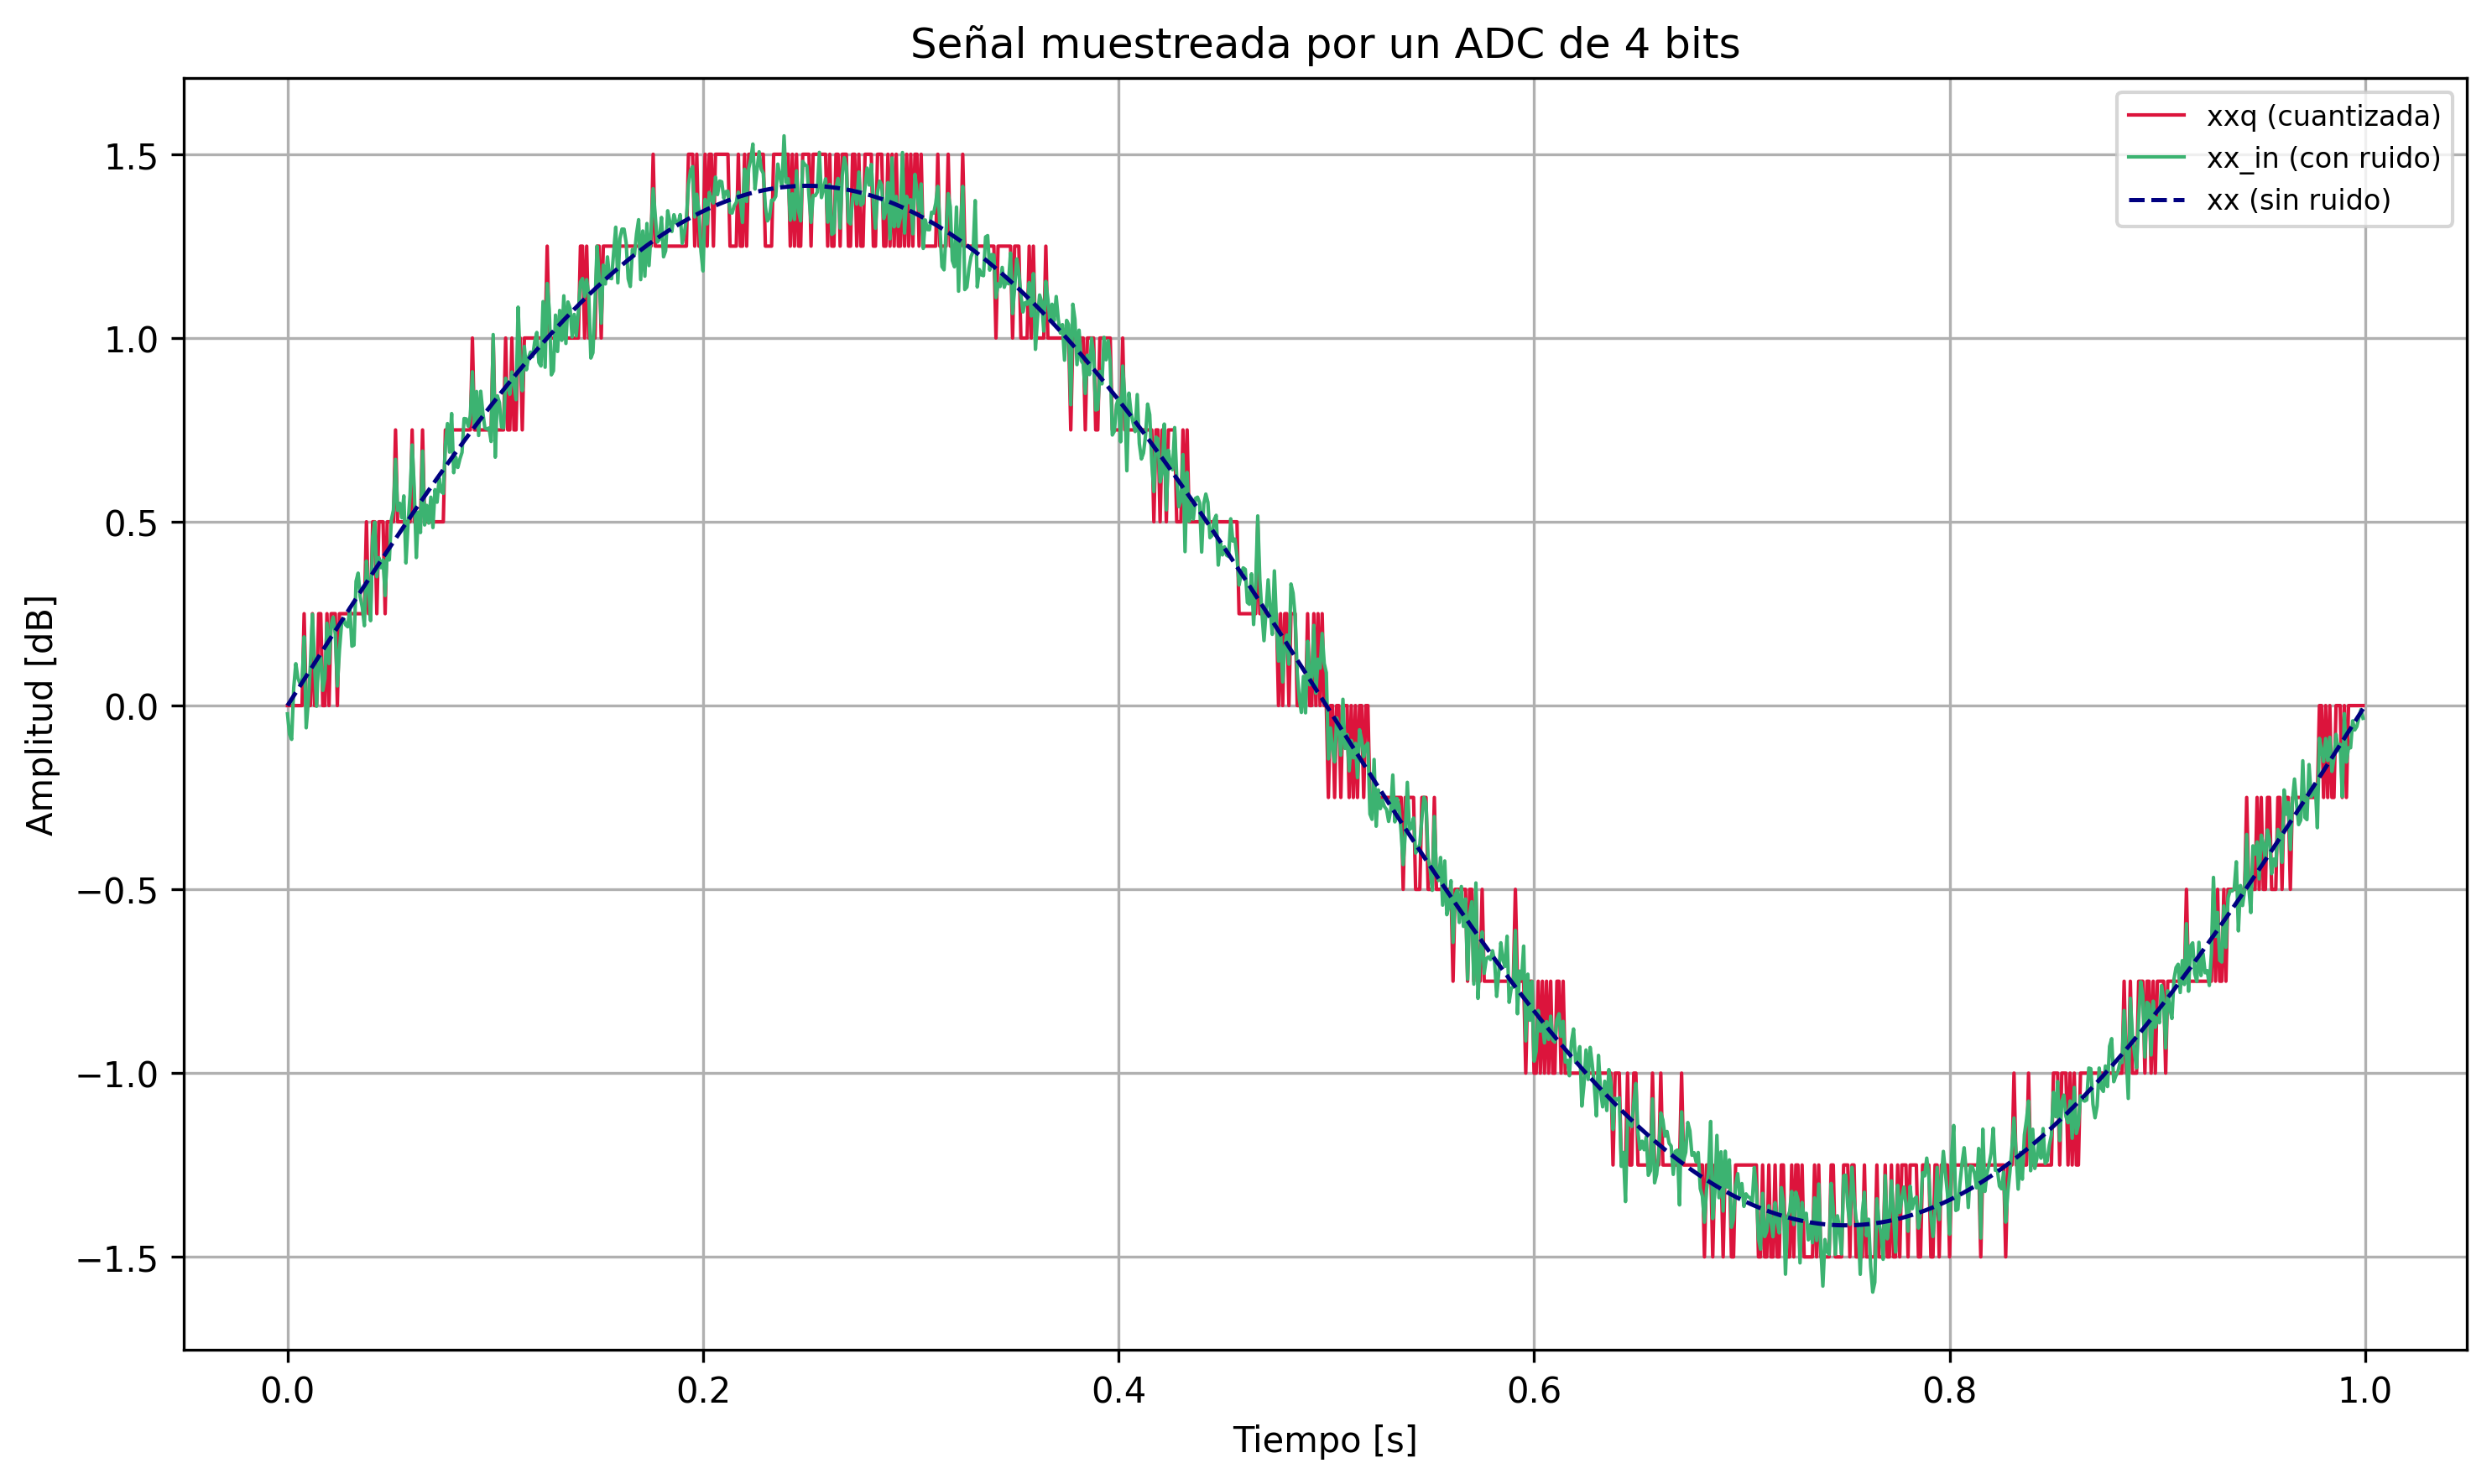

In [2]:
import matplotlib.pyplot as plt

vmax=np.sqrt(2) # para que la potencia sea 1 W
dc=0
ph=0 
nn=1000
fs=1000
ff=fs/nn

tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)

B = 4   # bits
Vfs = 2 # Volts
qq = (2*Vfs)/(2**B) # paso de cuantizacion
Pq = (qq**2) / 12  

kn = 1
potencia_ruido = kn * Pq

ruido=np.random.normal(0,np.sqrt(potencia_ruido),nn)    

yy = xx + ruido

xx_in = yy

xxq = np.round( xx_in / qq )  * qq   
                     
plt.figure(1, figsize=(10, 6), dpi=300)
           
plt.plot(tt, xxq, color = 'crimson', linewidth=1, label = 'xxq (cuantizada)')
plt.plot(tt, xx_in, color = 'mediumseagreen',  linewidth=1, label = 'xx_in (con ruido)')
plt.plot(tt, xx, color = 'navy', linewidth=1.2, linestyle='--', label = 'xx (sin ruido)')

plt.title('Señal muestreada por un ADC de 4 bits')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

En el gráfico se puede observar cómo la señal cuantizada (en rojo) adopta una forma de escalera. Esta es una característica de un ADC de baja resolución debido a que utilizar $B = 4$ equivale a 16 niveles de cuantización. Además, al ser $k_n = 1$, la potencia analógica va a ser igual a la digital, provocando fluctuaciones visibles en la señal de entrada que hacen que los saltos de los escalones sean irregulares.

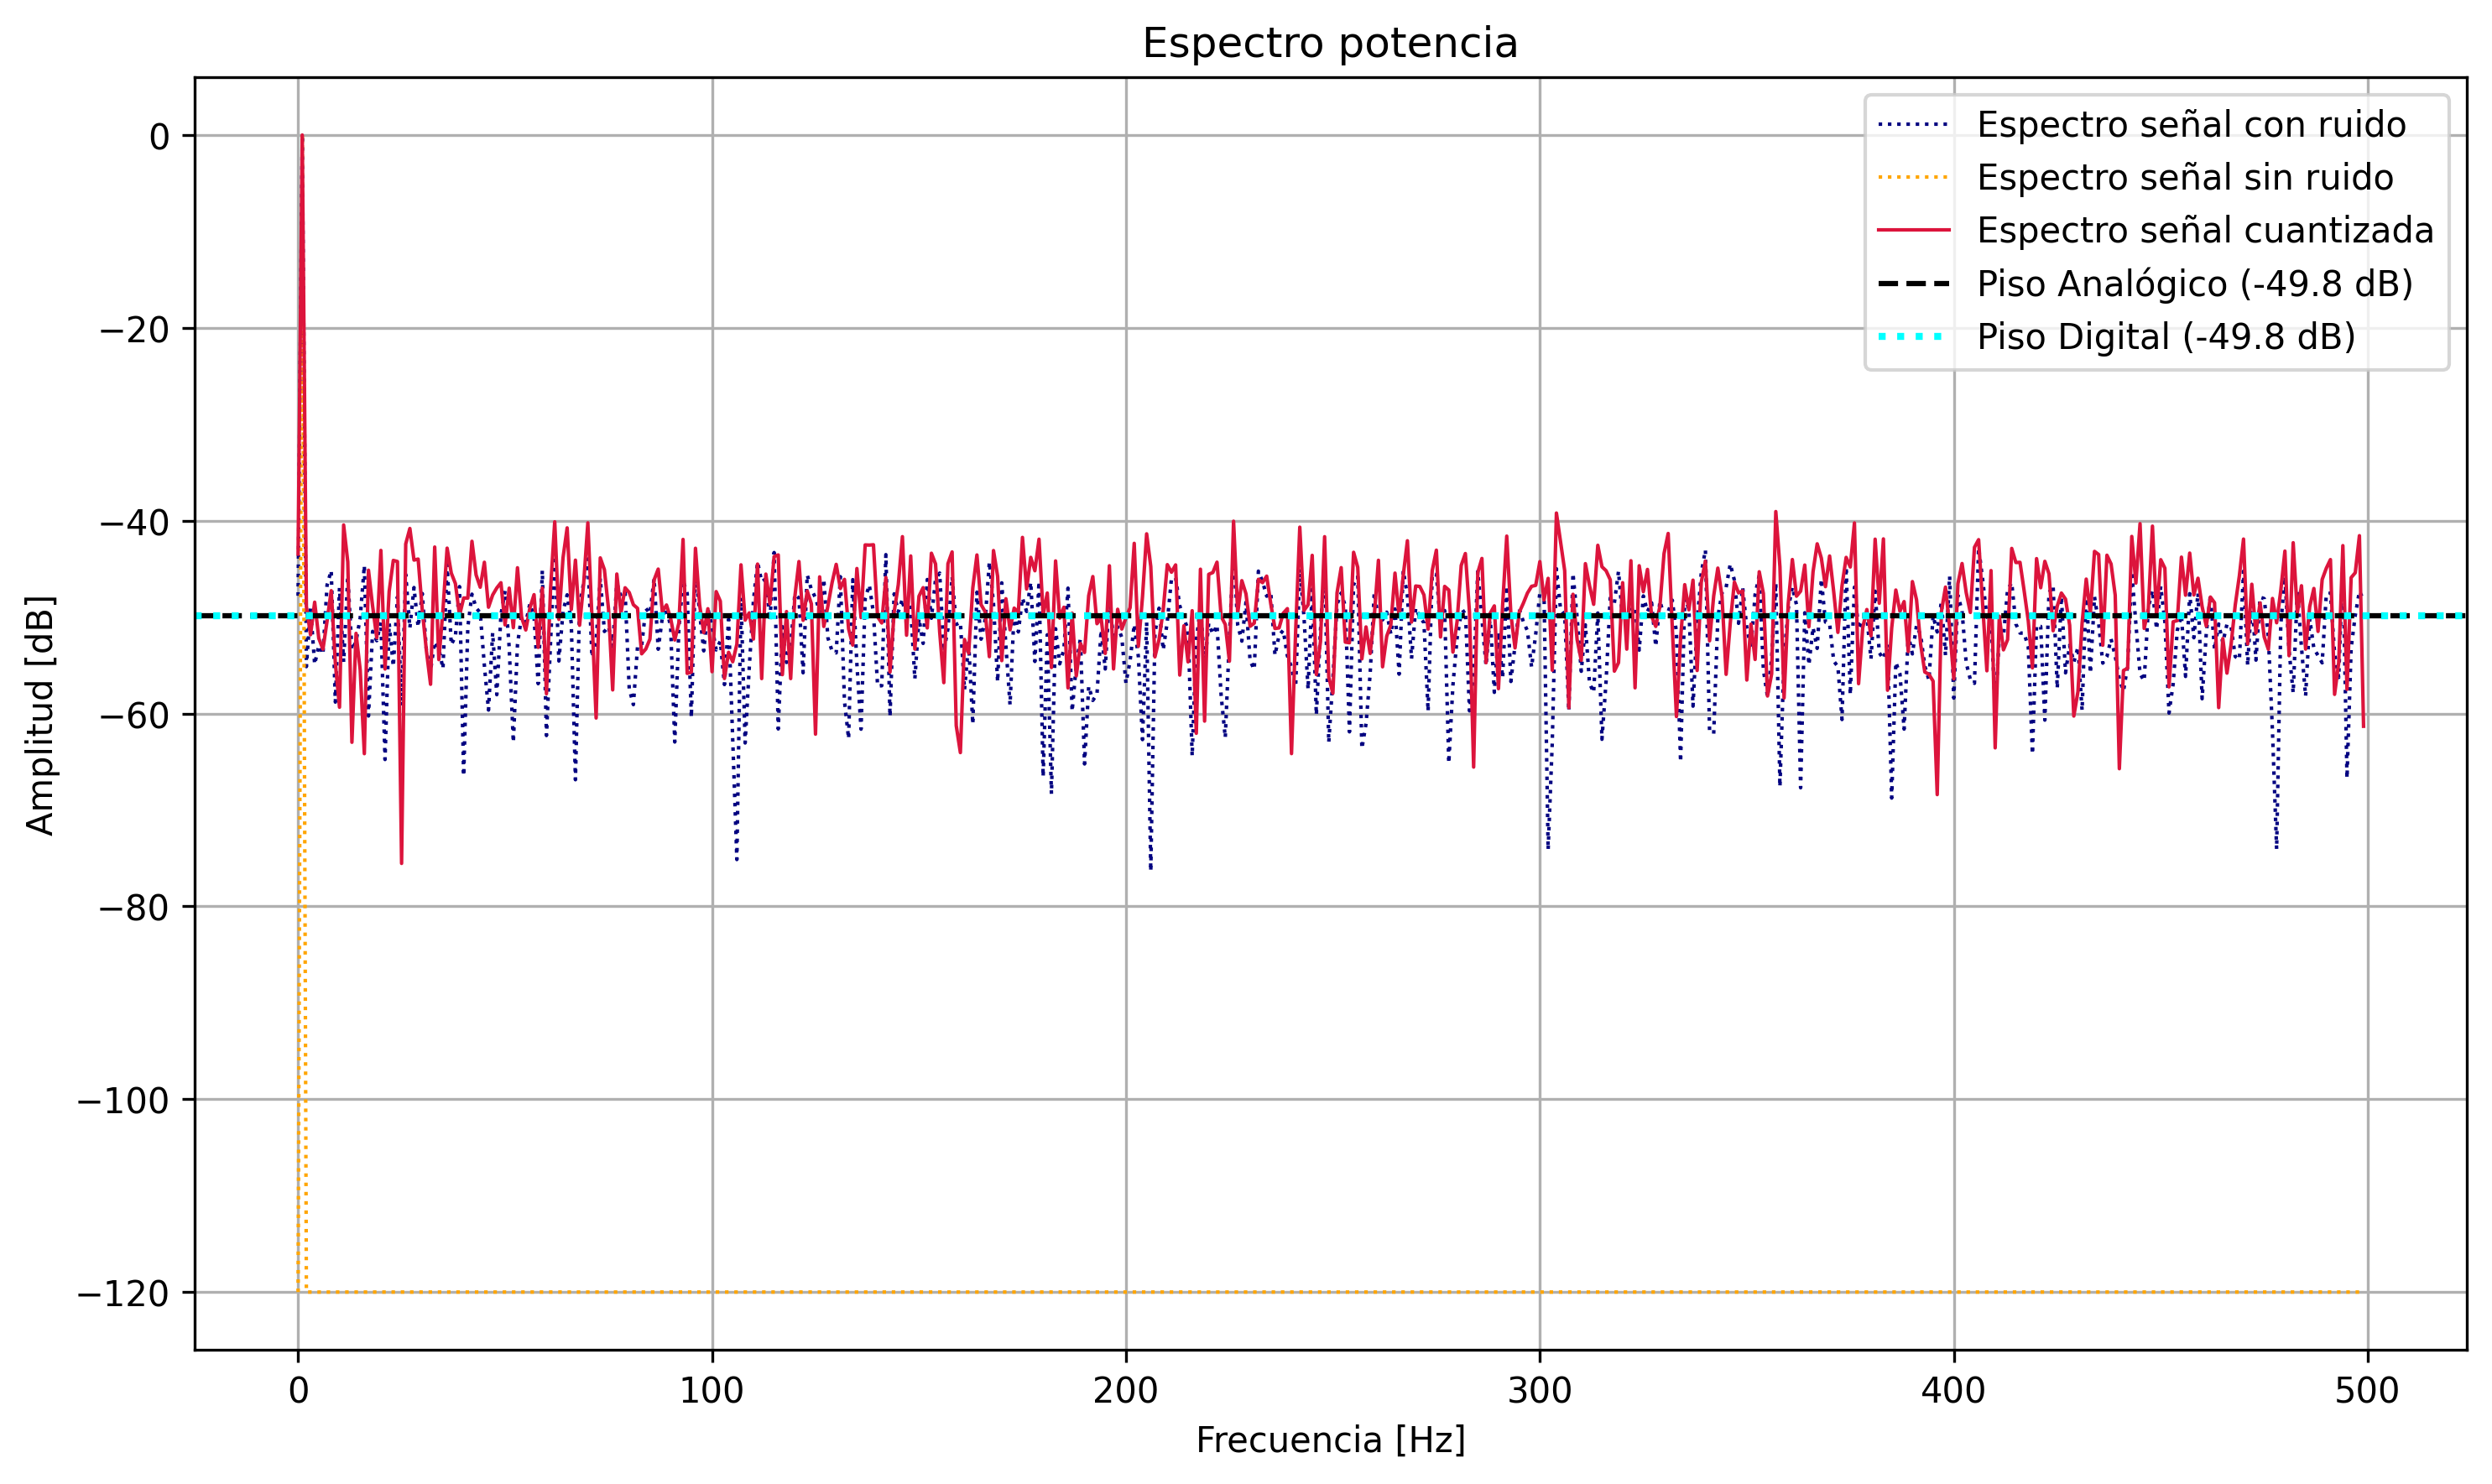

In [3]:
B = 4   # bits
Vfs = 2 # Volts
qq = (2*Vfs)/(2**B) # paso de cuantizacion
Pq = (qq**2) / 12  

kn = 1
potencia_ruido = kn * Pq

# SEÑAL CON RUIDO (yy)
YY = np.fft.fft(yy)
YYmod = np.abs(YY) / nn 
YYmod_cuadrado = 2 * (YYmod**2) 
YYesp_db = 10 * np.log10(YYmod_cuadrado + 1e-12 ) 
YY_mitad = YYesp_db[0:500] 

# SEÑAL SIN RUIDO (xx)
XX_fft = np.fft.fft(xx)
XXmod = np.abs(XX_fft) / nn
XXmod_cuadrado = 2 * (XXmod**2)
XX_esp_db = 10 * np.log10(XXmod_cuadrado + 1e-12 )
XX_mitad = XX_esp_db[0:500]

# SEÑAL CUANTIZADA (xxq)
XXQ_fft = np.fft.fft(xxq)
XXQ_mod = np.abs(XXQ_fft) / nn
XXQ_mod_cuadrado = 2 * (XXQ_mod**2)
XXQ_esp_db = 10 * np.log10(XXQ_mod_cuadrado + 1e-12 )
XXQ_mitad = XXQ_esp_db[0:500]

piso_digital = 10 * np.log10(Pq / (nn/2))
piso_analogico = 10 * np.log10(potencia_ruido / (nn/2))

plt.figure(3, figsize=(10, 6), dpi=300)
plt.plot(YY_mitad, color = 'navy', linewidth = 1, linestyle=':', label ='Espectro señal con ruido')
plt.plot(XX_mitad, color = 'orange', linewidth = 1, linestyle=':', label ='Espectro señal sin ruido')
plt.plot(XXQ_mitad, color = 'crimson', linewidth = 1, label ='Espectro señal cuantizada')
plt.axhline(y=piso_analogico, color='black', linestyle='--', linewidth=1.5, label=f'Piso Analógico ({piso_analogico:.1f} dB)')
plt.axhline(y=piso_digital, color='cyan', linestyle=':', linewidth=2, label=f'Piso Digital ({piso_digital:.1f} dB)')
plt.title('Espectro potencia')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Para el espectro de potencia, se puede distinguir el pico correspondiente a la frecuencia fundamental de la señal sinusoidal. Al haber un $k_n = 1$, las potencias de ruido analógico y del ruido de cuantización son equivalentes. En consecuencia, se observa que ambos pisos de ruido se superponen en el mismo nivel de amplitud. Por lo tanto, no dominará ninguno de los dos y el ruido final de la señal resultante será la suma de ambas contribuciones. 

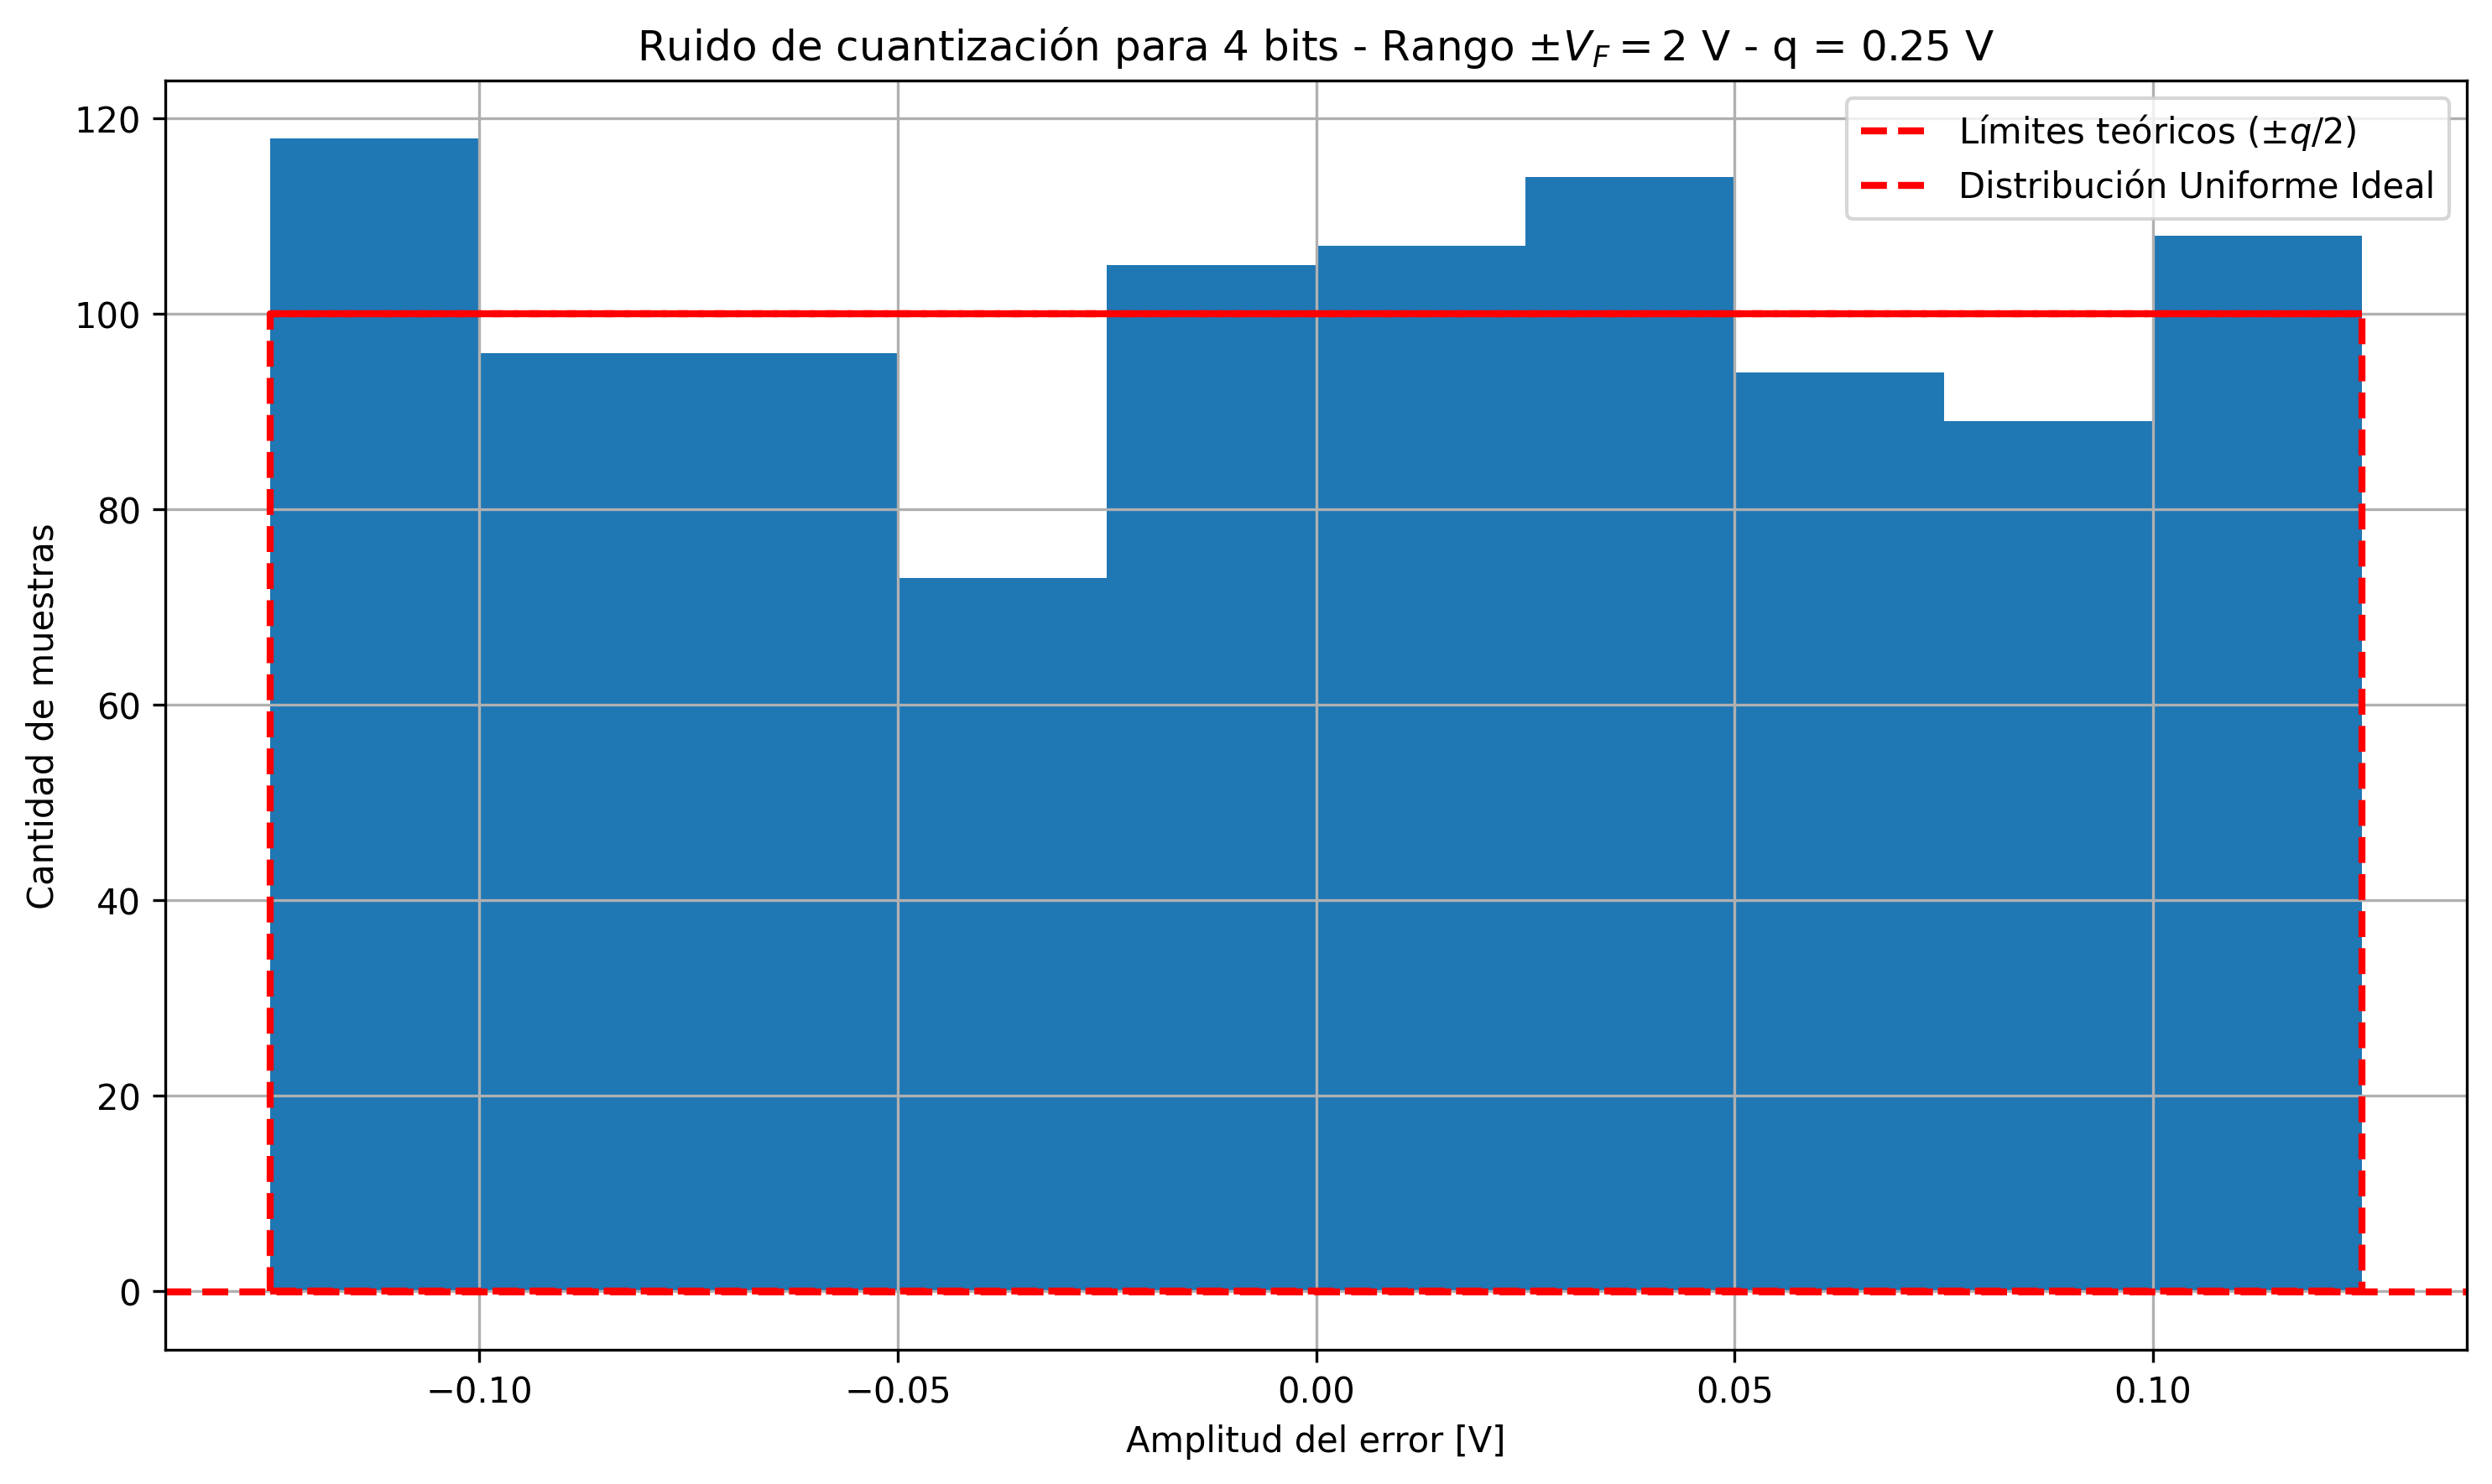

In [26]:
ruido_cuantizacion = xxq - xx_in 

plt.figure(figsize=(10, 6), dpi=300)

plt.hist(ruido_cuantizacion, bins=10, range=(-qq/2, qq/2), color='C0')

plt.axhline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos ($\pm q/2$)')

altura_ideal = nn / 10 
plt.plot([-qq/2, qq/2, qq/2, -qq/2, -qq/2], [0, 0, altura_ideal, altura_ideal, 0], 'r--', linewidth=2)
plt.title(f'Histograma del ruido de cuantización ({B} bits)')
plt.xlabel('Amplitud del error [V]')
plt.ylabel('Cantidad de muestras')
plt.grid(True)
plt.hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')
plt.title(f'Ruido de cuantización para {B} bits - Rango $\pm V_F = {Vfs}$ V - q = {qq} V')
plt.legend()
plt.tight_layout()
plt.show()


En el histograma se observa específicamente el error del ADC, es decir, la diferencia introducida al redondear la señal. Se puede observar que el error de cuantización sigue una distribución uniforme debido a que es independiente a la interferencia que tenga la señal analógica. Al ser ingresada por el ADC, se la redondea al valor más cercano. Por lo tanto, la distancia máxima que puede haber entre el valor original y valor cuantizado queda acotada entre los límites teóricos de $-\frac{q}{2}$ y $+\frac{q}{2}$. 

#### b. Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, $k_n$={1/10,1,10} . Discutir los resultados respecto a lo obtenido en a).

Para la segunda parte del primer ejercicio, se hará cada configuración de bits con cada $k_n$.
##### b.1) $B$ = 4

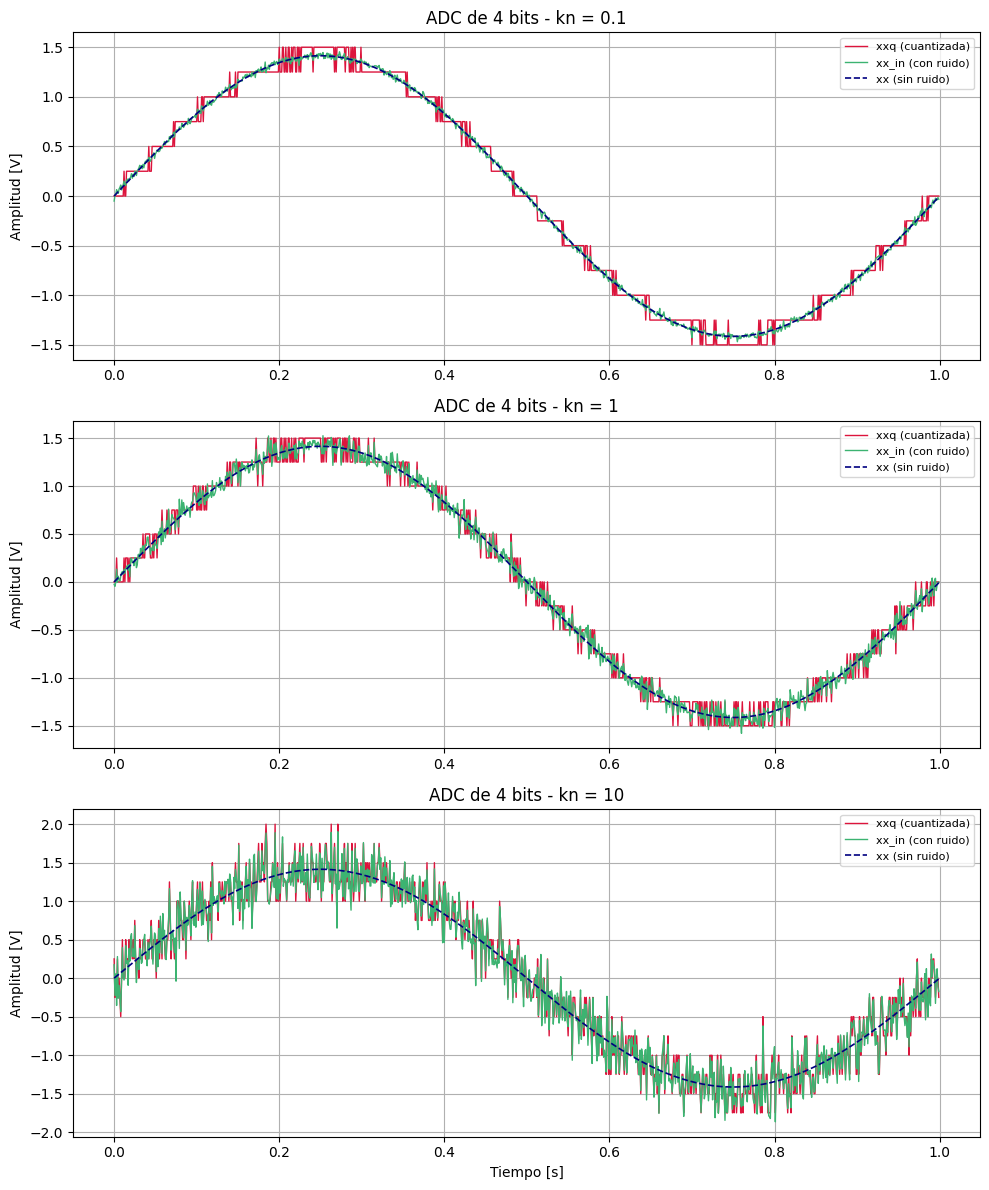

In [4]:
import numpy as np
import matplotlib.pyplot as plt

B_a = 4
Vfs = 2
qq = (2 * Vfs) / (2**B_a)
Pq = (qq**2) / 12  

fig, axs = plt.subplots(3, 1, figsize=(10, 12), dpi=100)

# kn = 1/10

kn_1 = 0.1
potencia_ruido_1 = kn_1 * Pq
ruido_1 = np.random.normal(0, np.sqrt(potencia_ruido_1), nn)
yy_1 = xx + ruido_1
xxq_1 = np.round(yy_1 / qq) * qq

axs[0].plot(tt, xxq_1, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[0].plot(tt, yy_1, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[0].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[0].set_title(f'ADC de {B_a} bits - kn = {kn_1}')
axs[0].set_ylabel('Amplitud [V]')
axs[0].grid(True)
axs[0].legend(loc='upper right', fontsize=8)

# kn = 1

kn_2 = 1
potencia_ruido_2 = kn_2 * Pq
ruido_2 = np.random.normal(0, np.sqrt(potencia_ruido_2), nn)
yy_2 = xx + ruido_2
xxq_2 = np.round(yy_2 / qq) * qq

axs[1].plot(tt, xxq_2, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[1].plot(tt, yy_2, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[1].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[1].set_title(f'ADC de {B_a} bits - kn = {kn_2}')
axs[1].set_ylabel('Amplitud [V]')
axs[1].grid(True)
axs[1].legend(loc='upper right', fontsize=8)

# kn = 10

kn_3 = 10
potencia_ruido_3 = kn_3 * Pq
ruido_3 = np.random.normal(0, np.sqrt(potencia_ruido_3), nn)
yy_3 = xx + ruido_3
xxq_3 = np.round(yy_3 / qq) * qq

axs[2].plot(tt, xxq_3, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[2].plot(tt, yy_3, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[2].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[2].set_title(f'ADC de {B_a} bits - kn = {kn_3}')
axs[2].set_ylabel('Amplitud [V]')
axs[2].set_xlabel('Tiempo [s]') 
axs[2].grid(True)
axs[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

En el primer caso, con $k_n = 0.1$, se observa que el ruido analógico es prácticamente nulo, por lo que la señal ingresada es muy limpia. Sin embargo, como $B = 4$ la señal resultante presenta una gran degradación debido al error de cuantización, ya que el problema principal es la falta de resolución del ADC. El segundo caso, donde $k_n$ = 1, fue explicado en el inciso anterior. Finalmente, para $k_n = 10$, el ruido analógico es tan grande que tapa casi completamente a los escalones de cuantización, por lo que la señal cuantizada saldrá con mucho ruido debido a la interferencia ingresada inicialmente. Esto es debido a que la potencia de ruido analógica es proporcional al $k_n$ junto con la potencia de ruido de cuantización, la cual a su vez depende del  paso de cuantización. 

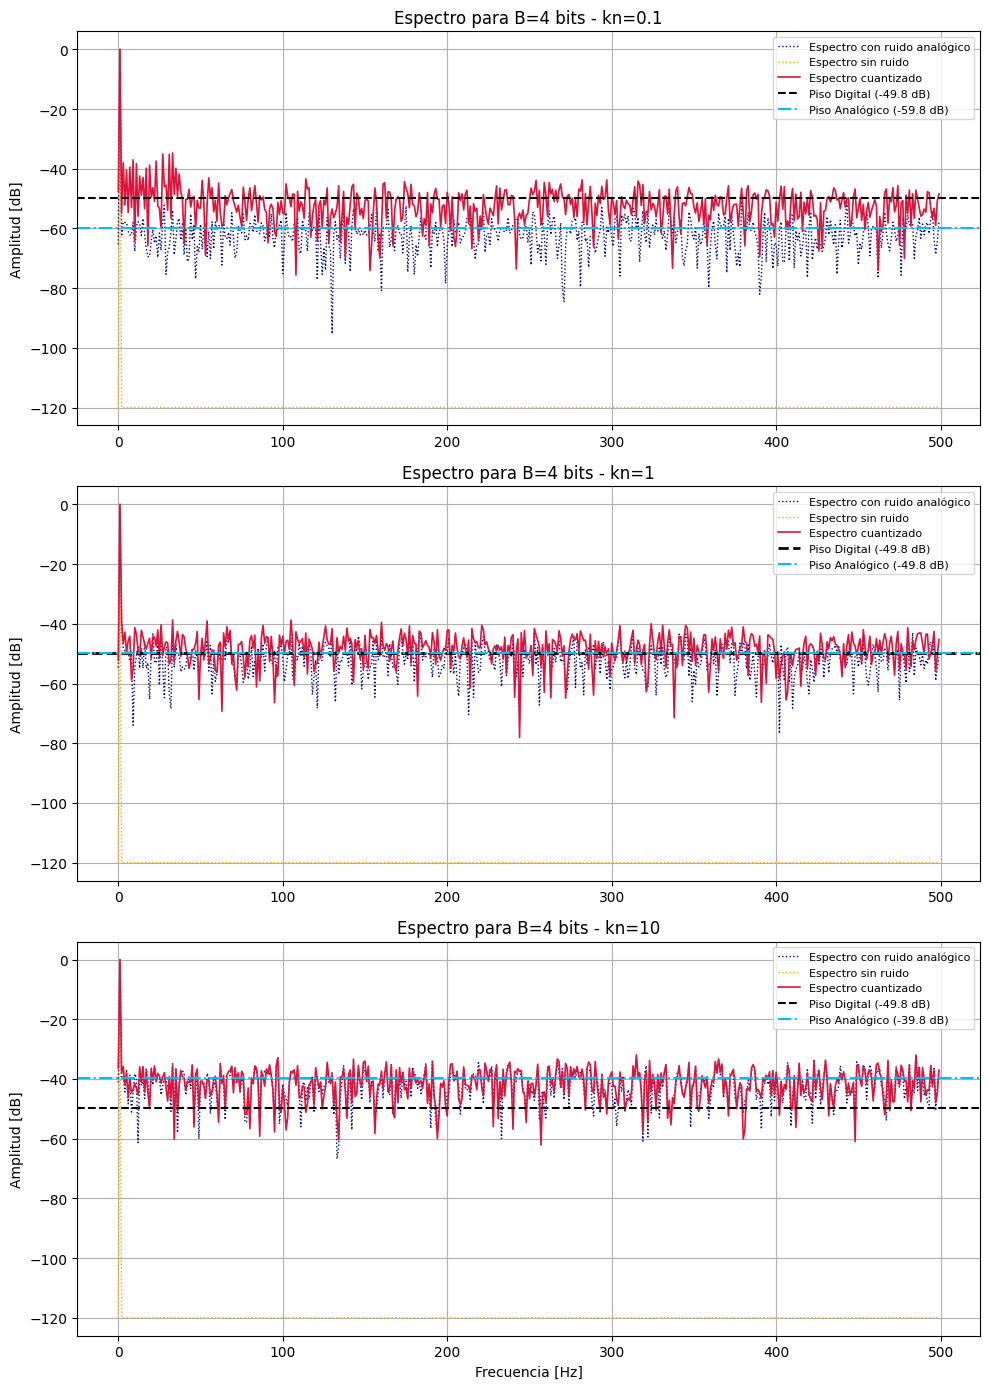

In [5]:
import numpy as np
import matplotlib.pyplot as plt

XX_fft = np.fft.fft(xx)
XXmod_cuadrado = 2 * (np.abs(XX_fft) / nn)**2
XX_esp_db = 10 * np.log10(XXmod_cuadrado + 1e-12)
XX_mitad = XX_esp_db[0:int(nn/2)]

piso_q_db = 10 * np.log10(Pq / (nn/2))

fig, axs = plt.subplots(3, 1, figsize=(10, 14), dpi=100)

# kn = 1/10

kn_1 = 0.1
potencia_ruido_1 = kn_1 * Pq
piso_n_db_1 = 10 * np.log10(potencia_ruido_1 / (nn/2)) 

yy_1 = xx + np.random.normal(0, np.sqrt(potencia_ruido_1), nn)
xxq_1 = np.round(yy_1 / qq) * qq

YY_esp_db_1 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_1)) / nn)**2 + 1e-12)
XXQ_esp_db_1 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_1)) / nn)**2 + 1e-12)

axs[0].plot(YY_esp_db_1[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[0].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[0].plot(XXQ_esp_db_1[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[0].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=1.5, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[0].axhline(y=piso_n_db_1, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_1:.1f} dB)')

axs[0].set_title(f'Espectro para B={B_a} bits - kn={kn_1}')
axs[0].set_ylabel('Amplitud [dB]')
axs[0].grid(True)
axs[0].legend(loc='upper right', fontsize=8)

# kn = 1

kn_2 = 1
potencia_ruido_2 = kn_2 * Pq
piso_n_db_2 = 10 * np.log10(potencia_ruido_2 / (nn/2)) 

yy_2 = xx + np.random.normal(0, np.sqrt(potencia_ruido_2), nn)
xxq_2 = np.round(yy_2 / qq) * qq

YY_esp_db_2 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_2)) / nn)**2 + 1e-12)
XXQ_esp_db_2 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_2)) / nn)**2 + 1e-12)

axs[1].plot(YY_esp_db_2[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[1].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[1].plot(XXQ_esp_db_2[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[1].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=2, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[1].axhline(y=piso_n_db_2, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_2:.1f} dB)')

axs[1].set_title(f'Espectro para B={B_a} bits - kn={kn_2}')
axs[1].set_ylabel('Amplitud [dB]')
axs[1].grid(True)
axs[1].legend(loc='upper right', fontsize=8)

# kn = 10

kn_3 = 10
potencia_ruido_3 = kn_3 * Pq
piso_n_db_3 = 10 * np.log10(potencia_ruido_3 / (nn/2)) 

yy_3 = xx + np.random.normal(0, np.sqrt(potencia_ruido_3), nn)
xxq_3 = np.round(yy_3 / qq) * qq

YY_esp_db_3 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_3)) / nn)**2 + 1e-12)
XXQ_esp_db_3 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_3)) / nn)**2 + 1e-12)

axs[2].plot(YY_esp_db_3[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[2].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[2].plot(XXQ_esp_db_3[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[2].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=1.5, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[2].axhline(y=piso_n_db_3, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_3:.1f} dB)')

axs[2].set_title(f'Espectro para B={B_a} bits - kn={kn_3}')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Amplitud [dB]')
axs[2].grid(True)
axs[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

El análisis espectral es útil para observar cuál error aporta la mayor potencia y en base a ella, cuál de los dos ruidos es el factor limitante en la calidad de la señal digitalizada. El piso de ruido digital es fijo ya que depende únicamente de los bits del ADC. Sin embargo, para los distintos $k_n$ se observan variaciones en el piso analógico. Para $k_n = 0.1$ el piso analógico está por debajo del digital, por lo que domina la cuantización. Para $k_n = 1$ los pisos son comparables y no domina ninguno de los dos. Por último, para $k_n = 10$ es fácil ver que el piso analógico está por encima del digital y, por lo tanto, domina el ruido analógico en el ruido final del sistema. 

Por último, para este primer caso el histograma es: 

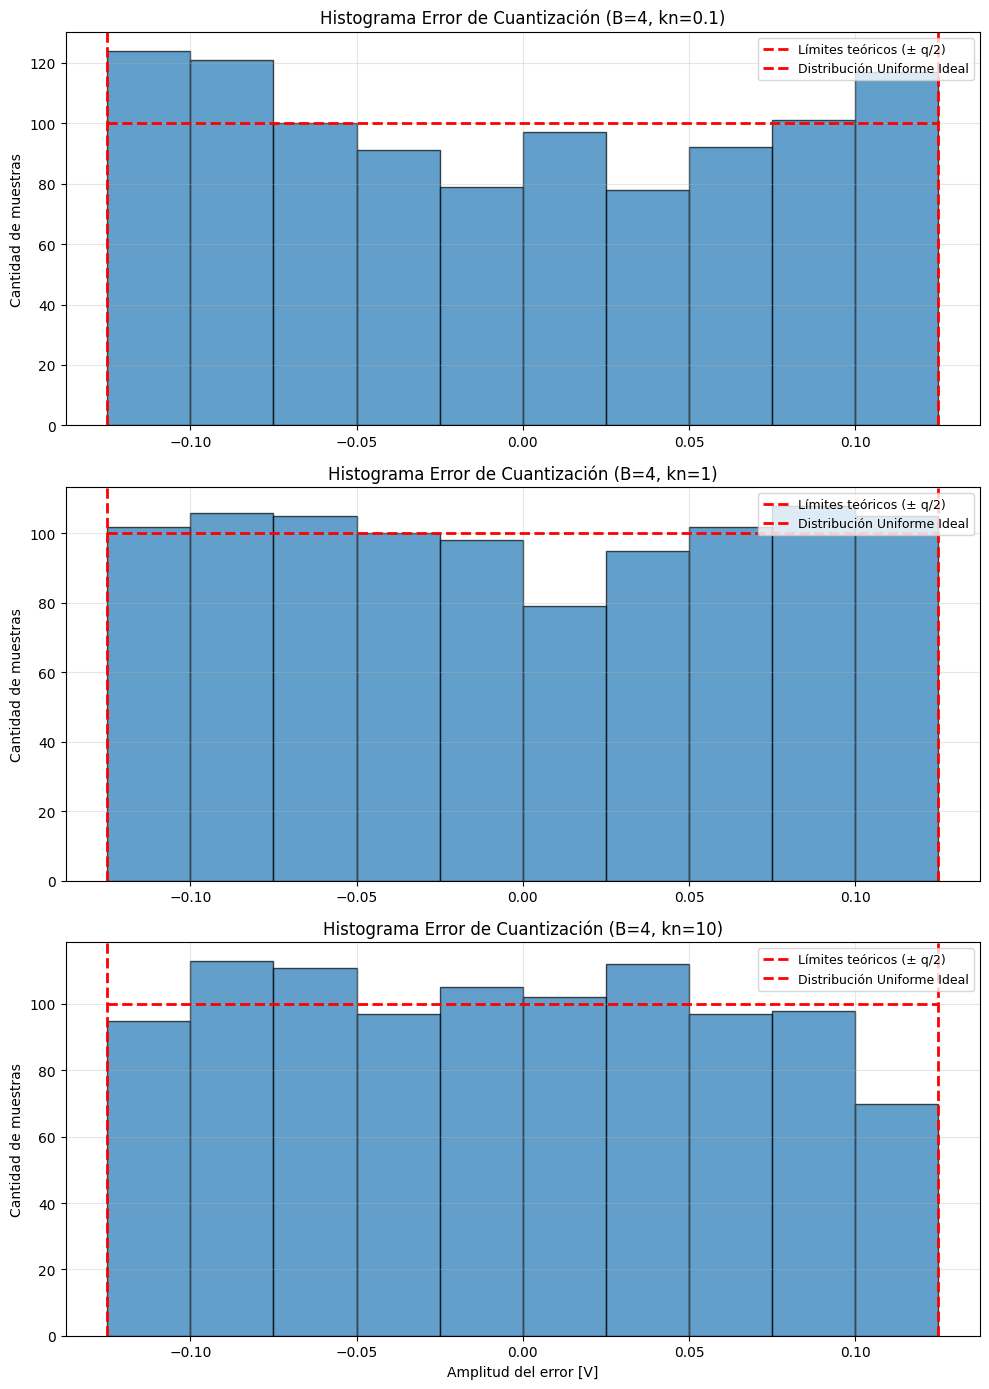

In [6]:
#%%
import numpy as np
import matplotlib.pyplot as plt

error_q_1 = xxq_1 - yy_1
error_q_2 = xxq_2 - yy_2
error_q_3 = xxq_3 - yy_3

bins_hist = 10
altura_ideal = nn / bins_hist

fig, axs = plt.subplots(3, 1, figsize=(10, 14), dpi=100)

# kn = 1/10

axs[0].hist(error_q_1, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[0].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[0].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[0].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[0].set_title(f'Histograma Error de Cuantización (B={B_a}, kn={kn_1})')
axs[0].set_ylabel('Cantidad de muestras')
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='upper right', fontsize=9)

# kn = 1

axs[1].hist(error_q_2, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[1].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[1].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[1].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[1].set_title(f'Histograma Error de Cuantización (B={B_a}, kn={kn_2})')
axs[1].set_ylabel('Cantidad de muestras')
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='upper right', fontsize=9)

# kn = 10

axs[2].hist(error_q_3, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[2].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[2].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[2].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[2].set_title(f'Histograma Error de Cuantización (B={B_a}, kn={kn_3})')
axs[2].set_xlabel('Amplitud del error [V]')
axs[2].set_ylabel('Cantidad de muestras')
axs[2].grid(True, alpha=0.3)
axs[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

Al evaluar los histogramas en conjunto, se puede determinar que el error de cuantización es siempre un error aleatorio, acotado entre los valores teóricos de $-\frac{q}{2}$ y $+\frac{q}{2}$, con una distribución uniforme. Es independiente al ruido analógico presente en la entrada.

##### b.2) $B$ = 8

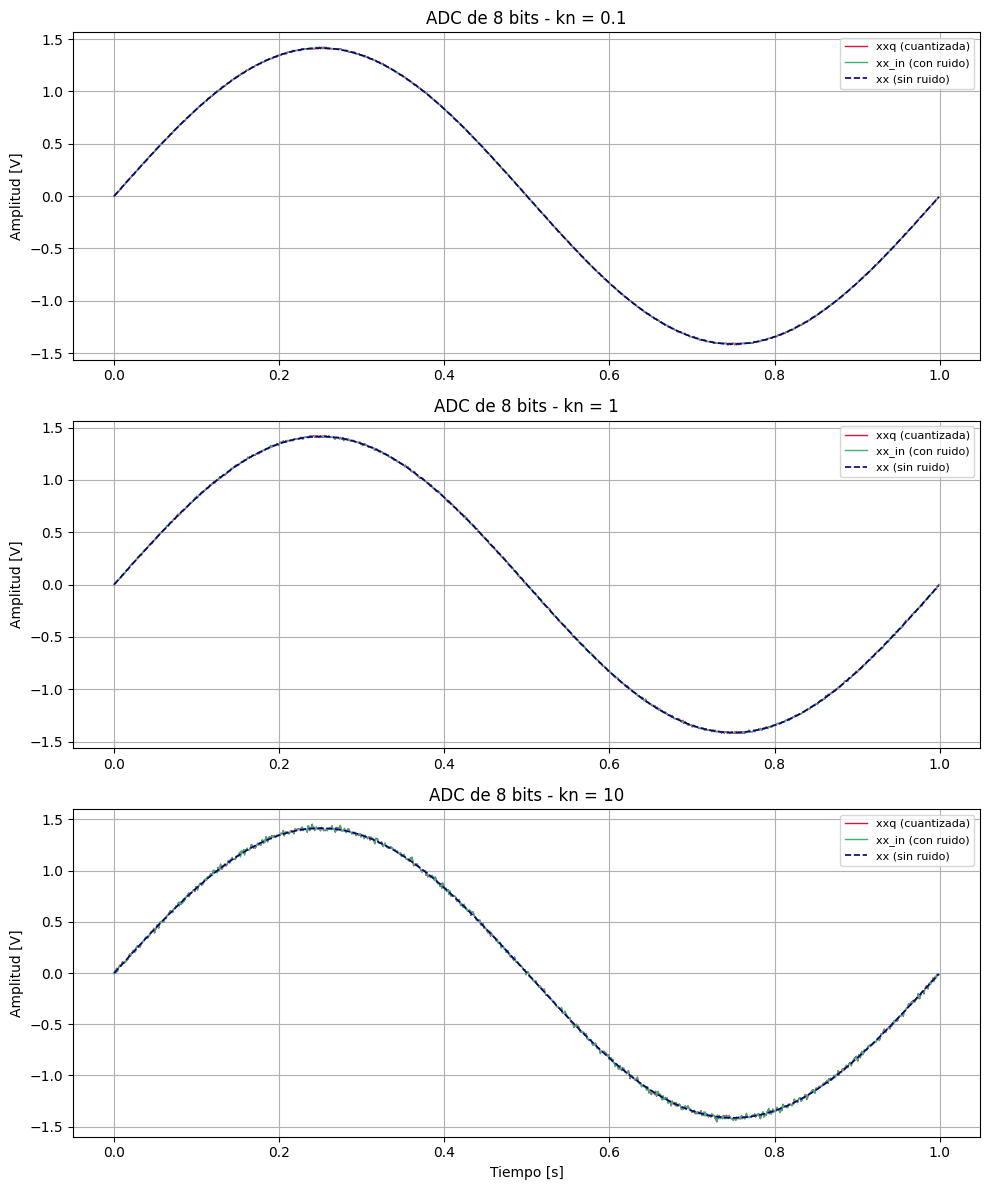

In [7]:
import numpy as np
import matplotlib.pyplot as plt

B_b = 8
Vfs = 2
qq = (2 * Vfs) / (2**B_b)
Pq = (qq**2) / 12  

fig, axs = plt.subplots(3, 1, figsize=(10, 12), dpi=100)

# kn = 1/10

kn_1 = 0.1
potencia_ruido_1 = kn_1 * Pq
ruido_1 = np.random.normal(0, np.sqrt(potencia_ruido_1), nn)
yy_1 = xx + ruido_1
xxq_1 = np.round(yy_1 / qq) * qq

axs[0].plot(tt, xxq_1, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[0].plot(tt, yy_1, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[0].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[0].set_title(f'ADC de {B_b} bits - kn = {kn_1}')
axs[0].set_ylabel('Amplitud [V]')
axs[0].grid(True)
axs[0].legend(loc='upper right', fontsize=8)


# kn = 1

kn_2 = 1
potencia_ruido_2 = kn_2 * Pq
ruido_2 = np.random.normal(0, np.sqrt(potencia_ruido_2), nn)
yy_2 = xx + ruido_2
xxq_2 = np.round(yy_2 / qq) * qq

axs[1].plot(tt, xxq_2, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[1].plot(tt, yy_2, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[1].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[1].set_title(f'ADC de {B_b} bits - kn = {kn_2}')
axs[1].set_ylabel('Amplitud [V]')
axs[1].grid(True)
axs[1].legend(loc='upper right', fontsize=8)


# kn = 10

kn_3 = 10
potencia_ruido_3 = kn_3 * Pq
ruido_3 = np.random.normal(0, np.sqrt(potencia_ruido_3), nn)
yy_3 = xx + ruido_3
xxq_3 = np.round(yy_3 / qq) * qq

axs[2].plot(tt, xxq_3, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[2].plot(tt, yy_3, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[2].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[2].set_title(f'ADC de {B_b} bits - kn = {kn_3}')
axs[2].set_ylabel('Amplitud [V]')
axs[2].set_xlabel('Tiempo [s]') 
axs[2].grid(True)
axs[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Al aumentar la resolución de bits a $B = 8$, se obtienen ahora niveles de cuantización de 256, lo que reduce significativamente el paso de cuantización ($q$). En consecuencia, dado que la potencia del ruido analógico es proporcional a este paso, el ruido analógico también disminuye. Por lo tanto, a medida que aumenta el ruido analógico por el factor $k_n$, para los primeros dos casos, donde $k_n = 0.1$ y $k_n = 1$, el error es casi imperceptible. Recién para el último caso, donde $k_n =10$, la señal se percibe apenas distorsionada, consecuencia del aumento del nivel de ruido analógico ingresado.  

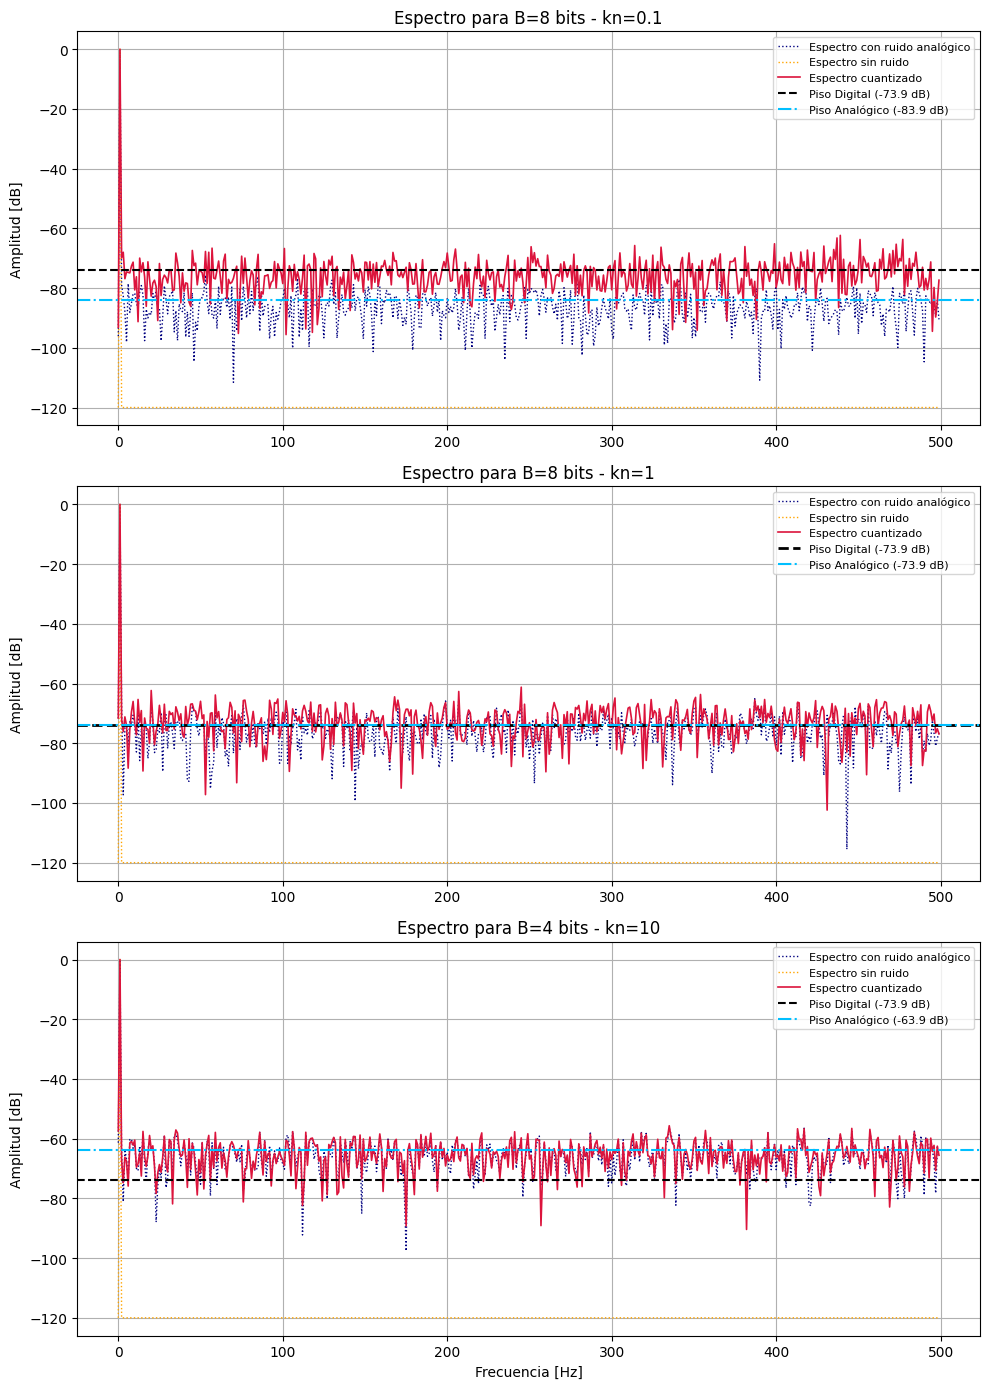

In [8]:
import numpy as np
import matplotlib.pyplot as plt

XX_fft = np.fft.fft(xx)
XXmod_cuadrado = 2 * (np.abs(XX_fft) / nn)**2
XX_esp_db = 10 * np.log10(XXmod_cuadrado + 1e-12)
XX_mitad = XX_esp_db[0:int(nn/2)]

piso_q_db = 10 * np.log10(Pq / (nn/2))

fig, axs = plt.subplots(3, 1, figsize=(10, 14), dpi=100)

# kn = 1/10

kn_1 = 0.1
potencia_ruido_1 = kn_1 * Pq
piso_n_db_1 = 10 * np.log10(potencia_ruido_1 / (nn/2))

yy_1 = xx + np.random.normal(0, np.sqrt(potencia_ruido_1), nn)
xxq_1 = np.round(yy_1 / qq) * qq

YY_esp_db_1 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_1)) / nn)**2 + 1e-12)
XXQ_esp_db_1 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_1)) / nn)**2 + 1e-12)

axs[0].plot(YY_esp_db_1[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[0].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[0].plot(XXQ_esp_db_1[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[0].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=1.5, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[0].axhline(y=piso_n_db_1, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_1:.1f} dB)')

axs[0].set_title(f'Espectro para B={B_b} bits - kn={kn_1}')
axs[0].set_ylabel('Amplitud [dB]')
axs[0].grid(True)
axs[0].legend(loc='upper right', fontsize=8)

# kn = 1

kn_2 = 1
potencia_ruido_2 = kn_2 * Pq
piso_n_db_2 = 10 * np.log10(potencia_ruido_2 / (nn/2)) 

yy_2 = xx + np.random.normal(0, np.sqrt(potencia_ruido_2), nn)
xxq_2 = np.round(yy_2 / qq) * qq

YY_esp_db_2 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_2)) / nn)**2 + 1e-12)
XXQ_esp_db_2 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_2)) / nn)**2 + 1e-12)

axs[1].plot(YY_esp_db_2[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[1].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[1].plot(XXQ_esp_db_2[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[1].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=2, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[1].axhline(y=piso_n_db_2, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_2:.1f} dB)')

axs[1].set_title(f'Espectro para B={B_b} bits - kn={kn_2}')
axs[1].set_ylabel('Amplitud [dB]')
axs[1].grid(True)
axs[1].legend(loc='upper right', fontsize=8)

# kn = 10

kn_3 = 10
potencia_ruido_3 = kn_3 * Pq
piso_n_db_3 = 10 * np.log10(potencia_ruido_3 / (nn/2)) 

yy_3 = xx + np.random.normal(0, np.sqrt(potencia_ruido_3), nn)
xxq_3 = np.round(yy_3 / qq) * qq

YY_esp_db_3 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_3)) / nn)**2 + 1e-12)
XXQ_esp_db_3 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_3)) / nn)**2 + 1e-12)

axs[2].plot(YY_esp_db_3[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[2].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[2].plot(XXQ_esp_db_3[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[2].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=1.5, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[2].axhline(y=piso_n_db_3, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_3:.1f} dB)')

axs[2].set_title(f'Espectro para B={B} bits - kn={kn_3}')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Amplitud [dB]')
axs[2].grid(True)
axs[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Analizando el espectro de potencia, la relación entre los pisos de acuerdo al $k_n$ se comporta de la misma manera que en el ADC de 4 bits. Además, otra característica en común es que para $k_n = 0.1$ domina el ruido de cuantización y para $k_n = 10$ domina el ruido analógico. Sin embargo, al disminuir drásticamente el paso de cuantización ($q$) al usar $B = 8$, tanto el piso como la potencia del ruido digital se hacen mucho más pequeños y, por lo tanto, la potencia del ruido analógico, junto con su piso correspondiente, toman niveles mucho más bajos.  

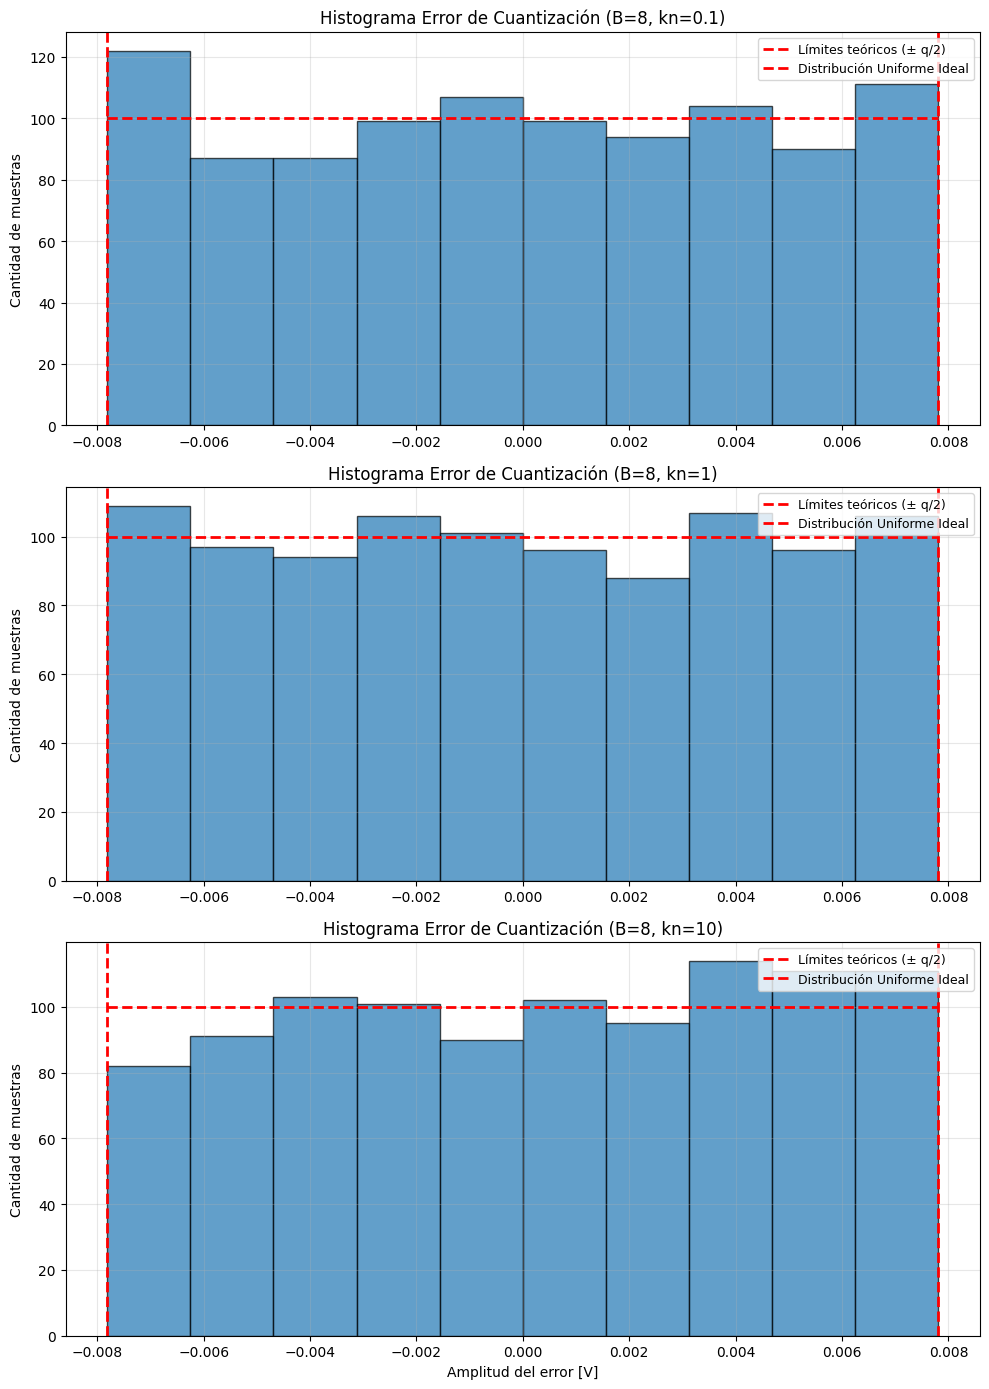

In [9]:
import numpy as np
import matplotlib.pyplot as plt

error_q_1 = xxq_1 - yy_1
error_q_2 = xxq_2 - yy_2
error_q_3 = xxq_3 - yy_3

bins_hist = 10
altura_ideal = nn / bins_hist 

fig, axs = plt.subplots(3, 1, figsize=(10, 14), dpi=100)

# kn = 1/10

axs[0].hist(error_q_1, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[0].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[0].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[0].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[0].set_title(f'Histograma Error de Cuantización (B={B_b}, kn={kn_1})')
axs[0].set_ylabel('Cantidad de muestras')
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='upper right', fontsize=9)

# kn = 1

axs[1].hist(error_q_2, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[1].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[1].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[1].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[1].set_title(f'Histograma Error de Cuantización (B={B_b}, kn={kn_2})')
axs[1].set_ylabel('Cantidad de muestras')
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='upper right', fontsize=9)

# kn = 10

axs[2].hist(error_q_3, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[2].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[2].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[2].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[2].set_title(f'Histograma Error de Cuantización (B={B_b}, kn={kn_3})')
axs[2].set_xlabel('Amplitud del error [V]')
axs[2].set_ylabel('Cantidad de muestras')
axs[2].grid(True, alpha=0.3)
axs[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

Los histogramas continúan mostrando una distribución uniforme perfecta, pero ahora ajustada a los nuevos y más estrechos límites de $\pm \frac{q}{2}$.

##### b.2) B = 16

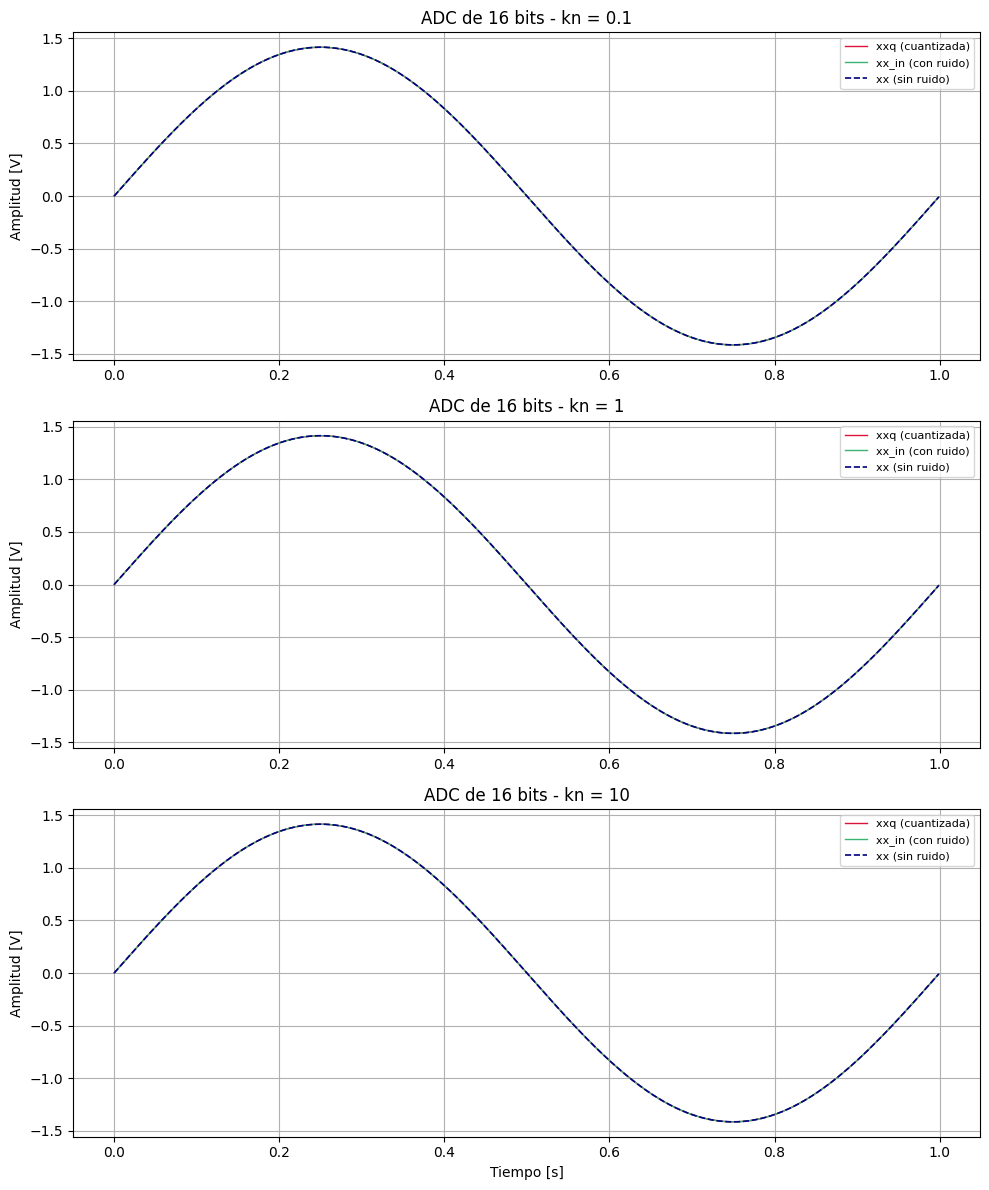

In [10]:
import numpy as np
import matplotlib.pyplot as plt

B_c = 16
Vfs = 2
qq = (2 * Vfs) / (2**B_c)
Pq = (qq**2) / 12  

fig, axs = plt.subplots(3, 1, figsize=(10, 12), dpi=100)

# kn = 1/10

kn_1 = 0.1
potencia_ruido_1 = kn_1 * Pq
ruido_1 = np.random.normal(0, np.sqrt(potencia_ruido_1), nn)
yy_1 = xx + ruido_1
xxq_1 = np.round(yy_1 / qq) * qq

axs[0].plot(tt, xxq_1, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[0].plot(tt, yy_1, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[0].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[0].set_title(f'ADC de {B_c} bits - kn = {kn_1}')
axs[0].set_ylabel('Amplitud [V]')
axs[0].grid(True)
axs[0].legend(loc='upper right', fontsize=8)


# kn = 1

kn_2 = 1
potencia_ruido_2 = kn_2 * Pq
ruido_2 = np.random.normal(0, np.sqrt(potencia_ruido_2), nn)
yy_2 = xx + ruido_2
xxq_2 = np.round(yy_2 / qq) * qq

axs[1].plot(tt, xxq_2, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[1].plot(tt, yy_2, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[1].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[1].set_title(f'ADC de {B_c} bits - kn = {kn_2}')
axs[1].set_ylabel('Amplitud [V]')
axs[1].grid(True)
axs[1].legend(loc='upper right', fontsize=8)


# kn = 10

kn_3 = 10
potencia_ruido_3 = kn_3 * Pq
ruido_3 = np.random.normal(0, np.sqrt(potencia_ruido_3), nn)
yy_3 = xx + ruido_3
xxq_3 = np.round(yy_3 / qq) * qq

axs[2].plot(tt, xxq_3, color='crimson', linewidth=1, label='xxq (cuantizada)')
axs[2].plot(tt, yy_3, color='mediumseagreen', linewidth=1, label='xx_in (con ruido)')
axs[2].plot(tt, xx, color='navy', linewidth=1.2, linestyle='--', label='xx (sin ruido)')
axs[2].set_title(f'ADC de {B_c} bits - kn = {kn_3}')
axs[2].set_ylabel('Amplitud [V]')
axs[2].set_xlabel('Tiempo [s]') 
axs[2].grid(True)
axs[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Finalmente, al aumentar la resolución a $B = 16$, se disponen de 65.536 niveles de cuantización y el paso de cuantización se vuelve demasiado pequeño, incluso más pequeño que en el caso anterior, donde $B = 8$. Al estar el ruido analógico definido en función de este paso, la potencia de ambos ruidos disminuye. Es por ello que, sin importar el $k_n$, la señal analógica se superpone perfectamente con la señal digitalizada. 

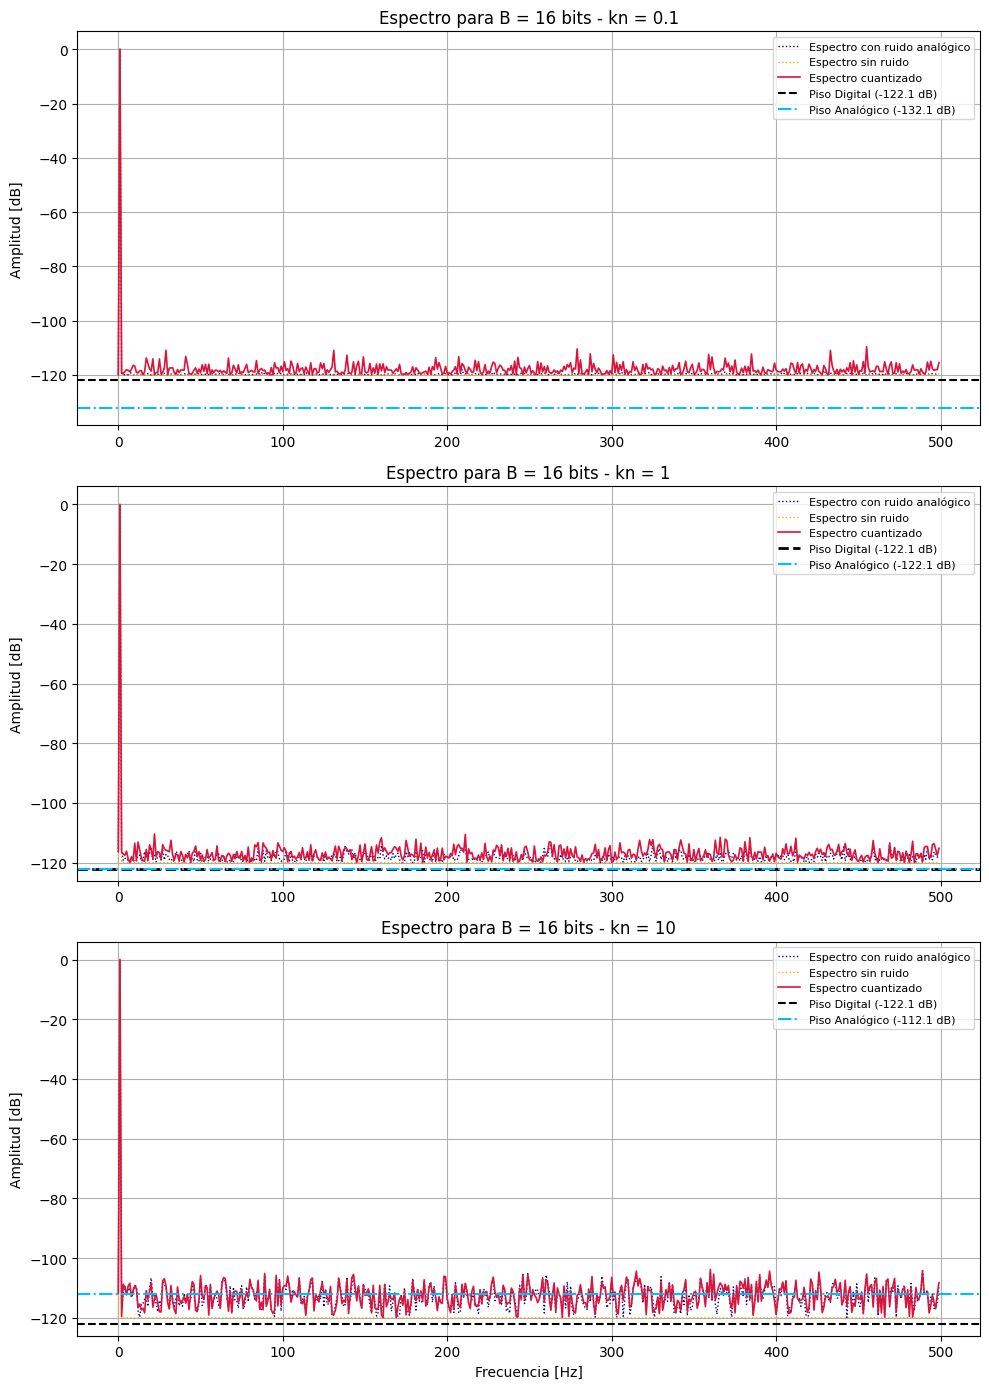

In [11]:
import numpy as np
import matplotlib.pyplot as plt

XX_fft = np.fft.fft(xx)
XXmod_cuadrado = 2 * (np.abs(XX_fft) / nn)**2
XX_esp_db = 10 * np.log10(XXmod_cuadrado + 1e-12)
XX_mitad = XX_esp_db[0:int(nn/2)]

piso_q_db = 10 * np.log10(Pq / (nn/2))

fig, axs = plt.subplots(3, 1, figsize=(10, 14), dpi=100)

# kn = 1/10

kn_1 = 0.1
potencia_ruido_1 = kn_1 * Pq
piso_n_db_1 = 10 * np.log10(potencia_ruido_1 / (nn/2)) 

yy_1 = xx + np.random.normal(0, np.sqrt(potencia_ruido_1), nn)
xxq_1 = np.round(yy_1 / qq) * qq

YY_esp_db_1 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_1)) / nn)**2 + 1e-12)
XXQ_esp_db_1 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_1)) / nn)**2 + 1e-12)

axs[0].plot(YY_esp_db_1[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[0].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[0].plot(XXQ_esp_db_1[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[0].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=1.5, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[0].axhline(y=piso_n_db_1, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_1:.1f} dB)')

axs[0].set_title(f'Espectro para B = {B_c} bits - kn = {kn_1}')
axs[0].set_ylabel('Amplitud [dB]')
axs[0].grid(True)
axs[0].legend(loc='upper right', fontsize=8)

# kn = 1

kn_2 = 1
potencia_ruido_2 = kn_2 * Pq
piso_n_db_2 = 10 * np.log10(potencia_ruido_2 / (nn/2)) 

yy_2 = xx + np.random.normal(0, np.sqrt(potencia_ruido_2), nn)
xxq_2 = np.round(yy_2 / qq) * qq

YY_esp_db_2 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_2)) / nn)**2 + 1e-12)
XXQ_esp_db_2 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_2)) / nn)**2 + 1e-12)

axs[1].plot(YY_esp_db_2[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[1].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[1].plot(XXQ_esp_db_2[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[1].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=2, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[1].axhline(y=piso_n_db_2, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_2:.1f} dB)')

axs[1].set_title(f'Espectro para B = {B_c} bits - kn = {kn_2}')
axs[1].set_ylabel('Amplitud [dB]')
axs[1].grid(True)
axs[1].legend(loc='upper right', fontsize=8)

# kn = 10

kn_3 = 10
potencia_ruido_3 = kn_3 * Pq
piso_n_db_3 = 10 * np.log10(potencia_ruido_3 / (nn/2)) 

yy_3 = xx + np.random.normal(0, np.sqrt(potencia_ruido_3), nn)
xxq_3 = np.round(yy_3 / qq) * qq

YY_esp_db_3 = 10 * np.log10(2 * (np.abs(np.fft.fft(yy_3)) / nn)**2 + 1e-12)
XXQ_esp_db_3 = 10 * np.log10(2 * (np.abs(np.fft.fft(xxq_3)) / nn)**2 + 1e-12)

axs[2].plot(YY_esp_db_3[0:int(nn/2)], color='navy', linewidth=1, linestyle=':', label='Espectro con ruido analógico')
axs[2].plot(XX_mitad, color='orange', linewidth=1, linestyle=':', label='Espectro sin ruido')
axs[2].plot(XXQ_esp_db_3[0:int(nn/2)], color='crimson', linewidth=1.2, label='Espectro cuantizado')

axs[2].axhline(y=piso_q_db, color='black', linestyle='--', linewidth=1.5, label=f'Piso Digital ({piso_q_db:.1f} dB)')
axs[2].axhline(y=piso_n_db_3, color='deepskyblue', linestyle='-.', linewidth=1.5, label=f'Piso Analógico ({piso_n_db_3:.1f} dB)')

axs[2].set_title(f'Espectro para B = {B_c} bits - kn = {kn_3}')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Amplitud [dB]')
axs[2].grid(True)
axs[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Al igual que en los casos de $B = 4$ y $B = 8$, los pisos de ruido descienden manteniendo sus distancias relativas en función del $k_n$ y ambos valores disminuyen drásticamente. Asimismo, para $k_n = 0.1$ el sistema está limitado por la cuantización, para $k_n = 1$ ambas potencias de ruido afectan por igual y para $k_n = 10$ está limitado por el ruido analógico. En este caso, debido al nuevo paso de cuantización, la potencia del ruido digital toma un valor muy pequeño y, en consecuencia, la del ruido analógico también. 


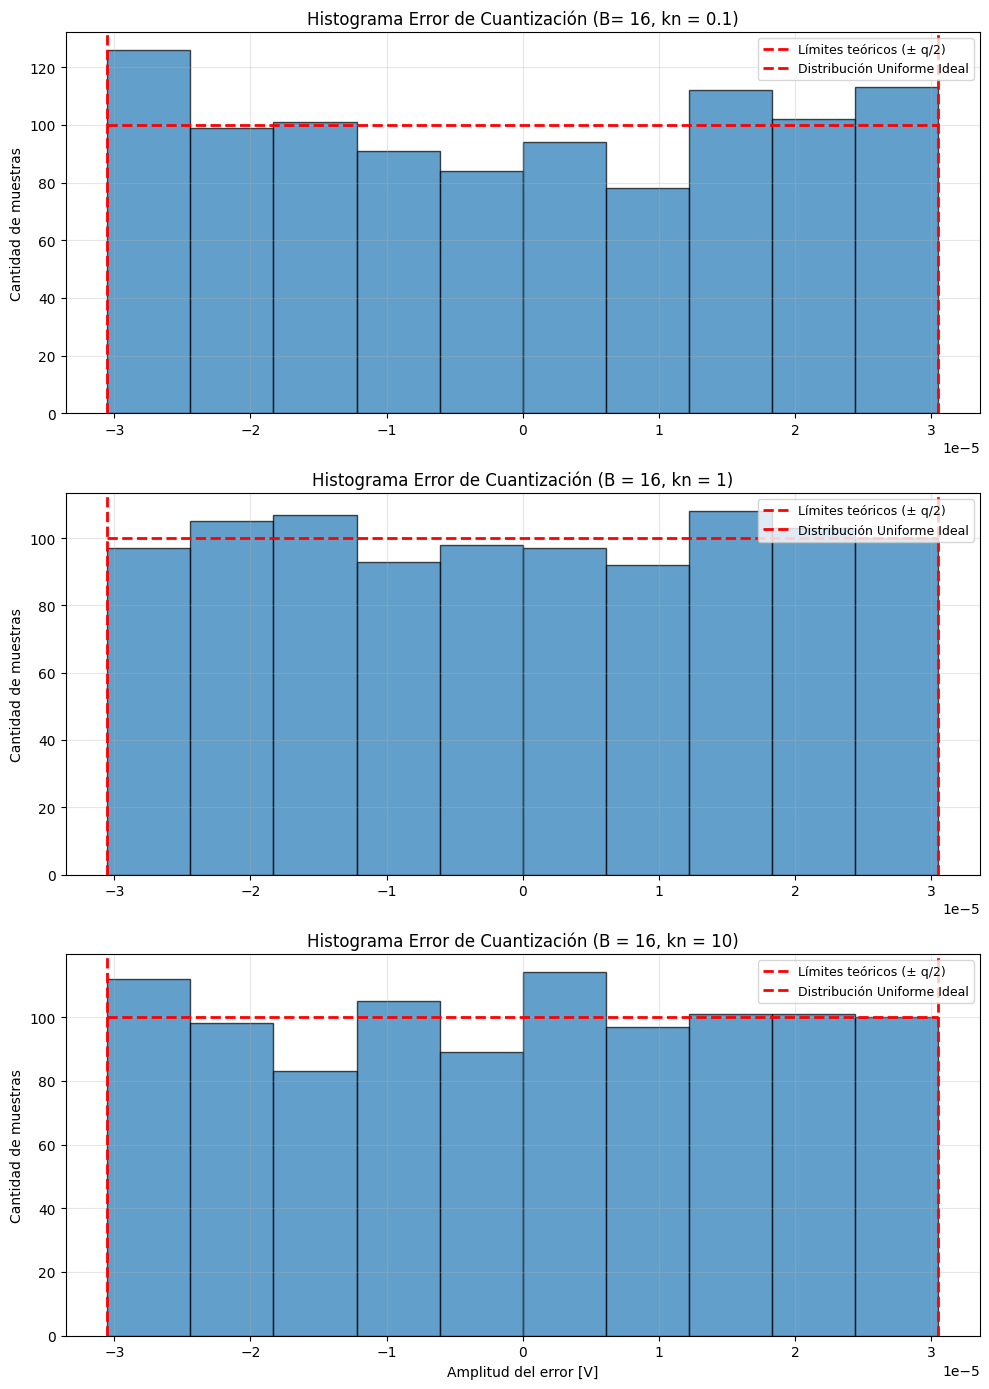

In [12]:
import numpy as np
import matplotlib.pyplot as plt

error_q_1 = xxq_1 - yy_1
error_q_2 = xxq_2 - yy_2
error_q_3 = xxq_3 - yy_3

bins_hist = 10
altura_ideal = nn / bins_hist 

fig, axs = plt.subplots(3, 1, figsize=(10, 14), dpi=100)

# kn = 1/10

axs[0].hist(error_q_1, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[0].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[0].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[0].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[0].set_title(f'Histograma Error de Cuantización (B= {B_c}, kn = {kn_1})')
axs[0].set_ylabel('Cantidad de muestras')
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='upper right', fontsize=9)

# kn = 1

axs[1].hist(error_q_2, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[1].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[1].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[1].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[1].set_title(f'Histograma Error de Cuantización (B = {B_c}, kn = {kn_2})')
axs[1].set_ylabel('Cantidad de muestras')
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='upper right', fontsize=9)

# kn = 10

axs[2].hist(error_q_3, bins=bins_hist, range=(-qq/2, qq/2), color='C0', edgecolor='black', alpha=0.7)
axs[2].axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='Límites teóricos (± q/2)')
axs[2].axvline(qq/2, color='red', linestyle='--', linewidth=2)
axs[2].hlines(y=altura_ideal, xmin=-qq/2, xmax=qq/2, color='red', linestyle='--', linewidth=2, label='Distribución Uniforme Ideal')

axs[2].set_title(f'Histograma Error de Cuantización (B = {B_c}, kn = {kn_3})')
axs[2].set_xlabel('Amplitud del error [V]')
axs[2].set_ylabel('Cantidad de muestras')
axs[2].grid(True, alpha=0.3)
axs[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

Por último, se puede observar como la distribución del error de cuantización es independiente del ruido analógico de entrada debido a que mantiene su distribución uniforme. Si bien está acotado entre $\pm \frac{q}{2}$, su distribución se mantiene constante.

### BONUS 

En [Holton. DSP Principles and App.](https://drive.google.com/file/d/1LyVqHSbS6ADjqBEWtL8ez1cAXmGbgOQK/view?usp=drive_link), se propone la relación entre la relación señal a ruido ($SNR$) de la señal digitalizada con la cantidad de $B$ bits con un voltaje full-scale $V_{FS}$, el paso de cuantización es: 

$$q = \frac{V_{FS}}{2^B}$$

Por lo que la potencia del ruido de cuantización resulta en: 

$$P_q = \frac{q^2}{12} = \frac{V_{FS}^2}{12 \cdot 2^{2B}}$$

La SNR está dada por la relación entre la potencia de la señal analógica ($P_s$) y la potencia del ruido de cuantización: 

$$SNR = \frac{P_s}{P_q} = \frac{{V_{rms}}^2}{\frac{V_{FS}^2}{12 \cdot 2^{2B}}}$$ 

Reemplazando los términos y aplicando logaritmo para obtener el valor en decibeles se obtiene: 

$$SNR_{dB} = 10 \cdot \log_{10}(\frac{12 \cdot 2^{2B}\cdot {V_{rms}}^2}{V_{FS}^2}) = 6.02B + 10.79 + 20\cdot\log_{10}(\frac{V_{rms}}{V_{FS}})$$

Esta relación significa que por cada bit ($B$) que se le agrega al ADC, la $SNR$ mejora en aproximadamente 6.02 dB. Esto se pudo observar gráficamente a medida que se fueron muestreando las señales notándose una disminución de ruido considerable al aumentar la cantidad de bits.


# Conclusión 

A partir de los resultados obtenidos se puede notar cómo al aumentar la cantidad de bits del ADC, el paso de cuantización disminuye drásticamente. Es por ello que, para una resolución de $B = 4$, la salida digitalizada va a contener un ruido y una potencia considerablemente mayores que la salida de un conversor de $B = 16$. En consecuencia, a medida que los bits aumentan y el ruido de cuantización se hace cada vez menor, la relación señal a ruido ($SNR$) mejora cada vez más.

Al analizar los distintos factores ($k_n$) se comprobó que la potencia total es aditiva. Para todos los casos donde ($k_n = 0.1$) se observó que el sistema se encontraba limitado por la cuantización. Por otro lado, para la totalidad de casos en los cuales $k_n = 10$ dominaba el ruido analógico. Con respecto a los casos con $k_n = 1$ ambos ruidos impactan de igual manera en la degradación de la señal. 

Los histogramas dieron como resultado una distribución uniforme sin importar la resolución aplicada al sistema ni el $k_n$. Además, siempre se mantuvieron entre los límites teóricos deseados $-\frac{q}{2}$ y $+\frac{q}{2}$, demostrando ser un proceso independiente de la magnitud del ruido analógico presente en la entrada.

